In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the 3 datasets 
df_tira = pd.read_csv('tira_campaign_data_with_nulls.csv')
df_purplle = pd.read_csv('purplle_campaign_data_with_nulls.csv')   
df_nykaa = pd.read_csv('nykaa_campaign_data_with_nulls.csv')

In [3]:
# Add brand column to each
df_tira['Brand'] = 'Tira'
df_purplle['Brand'] = 'Purplle'   
df_nykaa['Brand'] = 'Nykaa'

In [4]:
# Combine all into one DataFrame
df = pd.concat([df_tira, df_purplle, df_nykaa], ignore_index=True)

print("✅ All datasets loaded and combined!")
print(f"\n📊 Total rows: {df.shape[0]}")
print(f"📊 Total columns: {df.shape[1]}")
print(f"\n📋 Column names:\n{list(df.columns)}")

✅ All datasets loaded and combined!

📊 Total rows: 166665
📊 Total columns: 17

📋 Column names:
['Campaign_ID', 'Campaign_Type', 'Target_Audience', 'Duration', 'Channel_Used', 'Impressions', 'Clicks', 'Leads', 'Conversions', 'Revenue', 'Acquisition_Cost', 'ROI', 'Language', 'Engagement_Score', 'Customer_Segment', 'Date', 'Brand']


In [5]:
# Check missing values in detail
print("="*60)
print("MISSING VALUES COUNT PER COLUMN:")
print("="*60)
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])  # Show only columns with missing values

print("\n" + "="*60)
print("PERCENTAGE OF MISSING VALUES:")
print("="*60)
missing_percentage = (df.isnull().sum() / len(df)) * 100
print(missing_percentage[missing_percentage > 0])

print("\n" + "="*60)
print("DATA TYPES:")
print("="*60)
print(df.dtypes)

print("\n" + "="*60)
print("FIRST 3 ROWS:")
print("="*60)
print(df.head(3))

MISSING VALUES COUNT PER COLUMN:
Campaign_ID         5417
Campaign_Type       8358
Target_Audience     8172
Duration            8323
Channel_Used        8282
Impressions         8224
Clicks              8224
Leads               8090
Conversions         8000
Revenue             8304
Acquisition_Cost    8161
ROI                 8298
Language            8299
Engagement_Score    8081
Customer_Segment    8175
Date                8099
dtype: int64

PERCENTAGE OF MISSING VALUES:
Campaign_ID         3.250233
Campaign_Type       5.014850
Target_Audience     4.903249
Duration            4.993850
Channel_Used        4.969250
Impressions         4.934449
Clicks              4.934449
Leads               4.854049
Conversions         4.800048
Revenue             4.982450
Acquisition_Cost    4.896649
ROI                 4.978850
Language            4.979450
Engagement_Score    4.848648
Customer_Segment    4.905049
Date                4.859449
dtype: float64

DATA TYPES:
Campaign_ID             str
Cam

In [6]:
# Check if Channel_Used has multiple values 
print("="*60)
print("CHANNEL_USED - SAMPLE VALUES:")
print("="*60)
print(df['Channel_Used'].head(10))

print("\n" + "="*60)
print("UNIQUE VALUES IN Channel_Used (first 20):")
print("="*60)
print(df['Channel_Used'].unique()[:20])

CHANNEL_USED - SAMPLE VALUES:
0                            NaN
1                        YouTube
2                            NaN
3                         Google
4      Facebook, Email, WhatsApp
5               Google, Facebook
6       Email, YouTube, WhatsApp
7    Google, Facebook, Instagram
8                        YouTube
9      Email, WhatsApp, Facebook
Name: Channel_Used, dtype: str

UNIQUE VALUES IN Channel_Used (first 20):
<ArrowStringArray>
[                            nan,                       'YouTube',
                        'Google',     'Facebook, Email, WhatsApp',
              'Google, Facebook',      'Email, YouTube, WhatsApp',
   'Google, Facebook, Instagram',     'Email, WhatsApp, Facebook',
                      'WhatsApp',               'YouTube, Google',
  'YouTube, Instagram, Facebook',   'WhatsApp, YouTube, Facebook',
                      'Facebook',                     'Instagram',
      'Instagram, Email, Google',        'YouTube, Email, Google',
 'Facebook,

In [7]:
#  HANDLING MISSING VALUES
print("="*60)
print("BEFORE CLEANING:")
print("="*60)
print(f"Original dataset shape: {df.shape}")

df_clean = df.copy()

# 1. Drop rows where critical columns are missing
# These columns are essential for our analysis
critical_columns = ['Revenue', 'ROI', 'Channel_Used', 'Campaign_Type']
df_clean = df_clean.dropna(subset=critical_columns)

print(f"\nAfter dropping rows with missing critical columns: {df_clean.shape}")

# 2. Fill numerical columns with median
numerical_cols = ['Duration', 'Impressions', 'Clicks', 'Leads', 
                  'Conversions', 'Acquisition_Cost', 'Engagement_Score']

for col in numerical_cols:
    if col in df_clean.columns:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)

# 3. Fill categorical columns with mode 
categorical_cols = ['Campaign_ID', 'Target_Audience', 'Language', 
                    'Customer_Segment', 'Date']

for col in categorical_cols:
    if col in df_clean.columns:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)

print(f"\nAfter filling remaining missing values: {df_clean.shape}")

# 4. Verify no missing values remain
print("\n" + "="*60)
print("REMAINING MISSING VALUES:")
print("="*60)
print(df_clean.isnull().sum().sum())
print(f"✅ Total missing values left: {df_clean.isnull().sum().sum()}")

# 5. Remove duplicates if any
df_clean = df_clean.drop_duplicates()
print(f"\nAfter removing duplicates: {df_clean.shape}")

# 6. Final check
print("\n" + "="*60)
print("CLEAN DATASET INFO:")
print("="*60)
print(df_clean.info())

BEFORE CLEANING:
Original dataset shape: (166665, 17)

After dropping rows with missing critical columns: (135875, 17)

After filling remaining missing values: (135875, 17)

REMAINING MISSING VALUES:
0
✅ Total missing values left: 0

After removing duplicates: (135875, 17)

CLEAN DATASET INFO:
<class 'pandas.DataFrame'>
Index: 135875 entries, 1 to 166664
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       135875 non-null  str    
 1   Campaign_Type     135875 non-null  str    
 2   Target_Audience   135875 non-null  str    
 3   Duration          135875 non-null  float64
 4   Channel_Used      135875 non-null  str    
 5   Impressions       135875 non-null  float64
 6   Clicks            135875 non-null  float64
 7   Leads             135875 non-null  float64
 8   Conversions       135875 non-null  float64
 9   Revenue           135875 non-null  float64
 10  Acquisition_Cost  135875 non-

In [8]:
# Verify the cleaning worked
print("="*60)
print("SAMPLE OF CLEANED DATA (first 5 rows):")
print("="*60)
df_clean.head()

SAMPLE OF CLEANED DATA (first 5 rows):


,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date,Brand
1,TI-CMP-1001,Social Media,Tier 2 City Customers,24.0,YouTube,71795.0,2051.0,552.0,256.0,199168.0,316.36,1.46,Tamil,3.98,College Students,11-09-2024,Tira
3,TI-CMP-1003,Email,Youth,8.0,Google,31523.0,3721.0,2088.0,736.0,571872.0,161.13,3.82,Bengali,20.76,Youth,27-07-2024,Tira
5,TI-CMP-1005,Email,Tier 2 City Customers,6.0,"Google, Facebook",32340.0,4722.0,1102.0,698.0,185668.0,194.21,0.37,English,20.17,Tier 2 City Customers,26-09-2024,Tira
6,TI-CMP-1006,Social Media,Working Women,5.0,"Email, YouTube, WhatsApp",91729.0,13151.0,5556.0,4153.0,2691144.0,32.98,18.65,English,24.92,Premium Shoppers,08-02-2025,Tira
7,TI-CMP-1007,Social Media,Working Women,21.0,"Google, Facebook, Instagram",65005.0,7269.0,3868.0,2118.0,1230558.0,208.37,3.12,Bengali,20.39,College Students,14-11-2024,Tira


In [9]:
# MULTI-LABEL ENCODING FOR Channel_Used
from sklearn.preprocessing import MultiLabelBinarizer
# Convert NaN to empty string and then split
def split_channels(channel_str):
    if pd.isna(channel_str) or channel_str == '':
        return []
    return [ch.strip() for ch in channel_str.split(',')]

# Apply the split function to create a list of channels
df_clean['Channels_List'] = df_clean['Channel_Used'].apply(split_channels)

# Display sample
print("SAMPLE OF CHANNELS_LIST:")
print(df_clean[['Channel_Used', 'Channels_List']].head(10))

# Create multi-label encoder
mlb = MultiLabelBinarizer()

# Fit and transform the channels list
channel_encoded = mlb.fit_transform(df_clean['Channels_List'])

# Create DataFrame with encoded channels
channel_df = pd.DataFrame(channel_encoded, 
                          columns=[f'Channel_{col}' for col in mlb.classes_],
                          index=df_clean.index)

print("\n" + "="*60)
print(f"ENCODED CHANNELS SHAPE: {channel_df.shape}")
print(f"CHANNELS FOUND: {list(mlb.classes_)}")
print("="*60)

# Display first 5 rows of encoded channels
print("\nFIRST 5 ROWS OF ENCODED CHANNELS:")
print(channel_df.head())

# Add encoded channels to main dataframe
df_clean = pd.concat([df_clean, channel_df], axis=1)

# Drop the original Channel_Used and the temporary Channels_List
df_clean = df_clean.drop(['Channel_Used', 'Channels_List'], axis=1)

print("\n" + "="*60)
print("DATAFRAME SHAPE AFTER MULTI-LABEL ENCODING:")
print(f"Rows: {df_clean.shape[0]}, Columns: {df_clean.shape[1]}")
print("="*60)
print("\nALL COLUMNS NOW:")
print(list(df_clean.columns))

SAMPLE OF CHANNELS_LIST:
                    Channel_Used                   Channels_List
1                        YouTube                       [YouTube]
3                         Google                        [Google]
5               Google, Facebook              [Google, Facebook]
6       Email, YouTube, WhatsApp      [Email, YouTube, WhatsApp]
7    Google, Facebook, Instagram   [Google, Facebook, Instagram]
8                        YouTube                       [YouTube]
9      Email, WhatsApp, Facebook     [Email, WhatsApp, Facebook]
10                      WhatsApp                      [WhatsApp]
11               YouTube, Google               [YouTube, Google]
12  YouTube, Instagram, Facebook  [YouTube, Instagram, Facebook]

ENCODED CHANNELS SHAPE: (135875, 6)
CHANNELS FOUND: ['Email', 'Facebook', 'Google', 'Instagram', 'WhatsApp', 'YouTube']

FIRST 5 ROWS OF ENCODED CHANNELS:
   Channel_Email  Channel_Facebook  Channel_Google  Channel_Instagram  \
1              0               

In [10]:
# STEP 6: CREATE PROFIT_FLAG FROM ROI

# ROI is numeric
df_clean['ROI'] = pd.to_numeric(df_clean['ROI'], errors='coerce')

# Create Profit_Flag: 1 if ROI > 0 (profit), 0 if ROI <= 0 (loss)
df_clean['Profit_Flag'] = (df_clean['ROI'] > 0).astype(int)

print("="*60)
print("PROFIT_FLAG CREATED:")
print("="*60)
print(f"Profit (1) count: {df_clean['Profit_Flag'].sum()}")
print(f"Loss (0) count: {len(df_clean) - df_clean['Profit_Flag'].sum()}")
print(f"\nProfit_Flag distribution:")
print(df_clean['Profit_Flag'].value_counts())

# ROI statistics Check
print("\n" + "="*60)
print("ROI STATISTICS:")
print("="*60)
print(df_clean['ROI'].describe())

#  final dataframe shape
print("\n" + "="*60)
print("FINAL DATAFRAME SHAPE:")
print(f"Rows: {df_clean.shape[0]}, Columns: {df_clean.shape[1]}")
print("="*60)

PROFIT_FLAG CREATED:
Profit (1) count: 103447
Loss (0) count: 32428

Profit_Flag distribution:
Profit_Flag
1    103447
0     32428
Name: count, dtype: int64

ROI STATISTICS:
count    135875.000000
mean          2.699175
std           4.501566
min          -0.990000
25%           0.050000
50%           1.240000
75%           3.580000
max          79.300000
Name: ROI, dtype: float64

FINAL DATAFRAME SHAPE:
Rows: 135875, Columns: 23


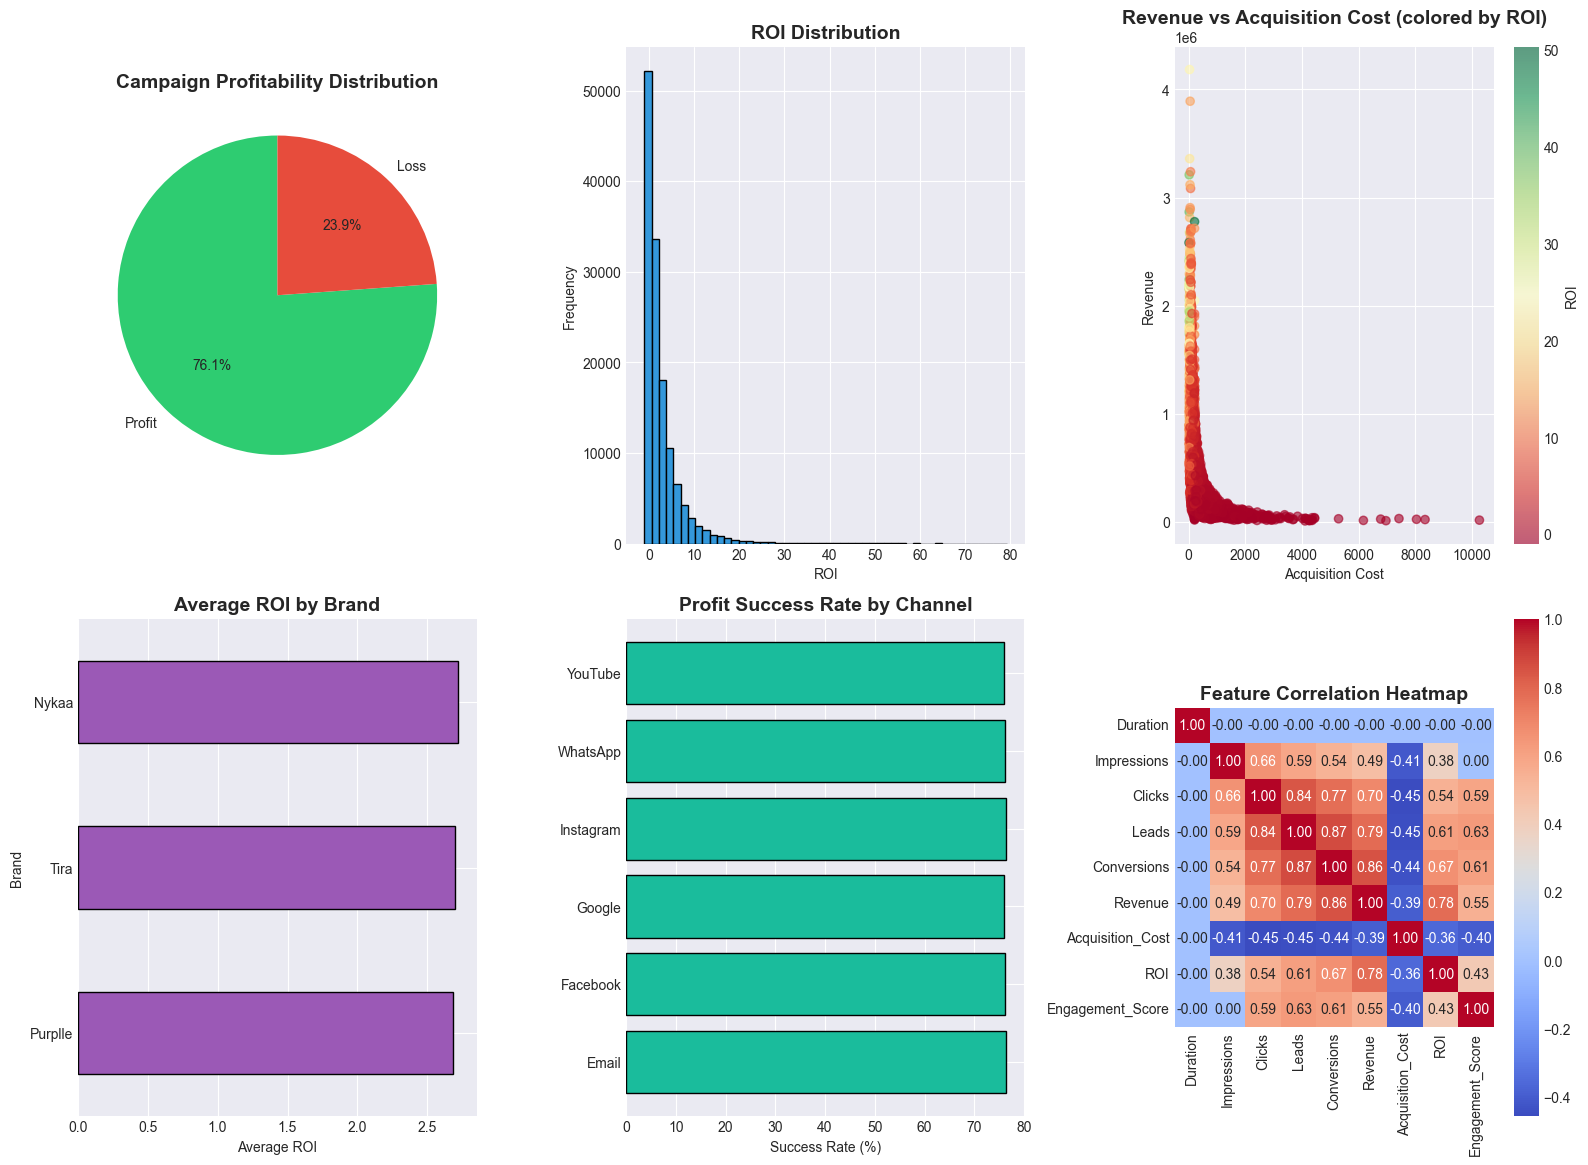


KEY INSIGHTS FROM EDA:
1. Total Campaigns: 135,875
2. Profitable Campaigns: 103,447 (76.1%)
3. Average ROI: 2.70
4. Best Performing Brand: Nykaa (ROI: 2.72)
5. Worst Performing Brand: Purplle (ROI: 2.68)

CHANNEL PERFORMANCE SUMMARY:
Email      : Success Rate = 76.4%
Facebook   : Success Rate = 76.2%
Google     : Success Rate = 75.9%
Instagram  : Success Rate = 76.5%
WhatsApp   : Success Rate = 76.2%
YouTube    : Success Rate = 76.0%


In [11]:
# EXPLORATORY DATA ANALYSIS (EDA)

import matplotlib.pyplot as plt
import seaborn as sns

# style for better looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create a figure with multiple subplots
fig = plt.figure(figsize=(16, 12))

# 1. Profit vs Loss Distribution (Pie Chart)
ax1 = fig.add_subplot(2, 3, 1)
profit_counts = df_clean['Profit_Flag'].value_counts()
colors = ['#2ecc71', '#e74c3c']
ax1.pie(profit_counts, labels=['Profit', 'Loss'], autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Campaign Profitability Distribution', fontsize=14, fontweight='bold')

# 2. ROI Distribution (Histogram)
ax2 = fig.add_subplot(2, 3, 2)
df_clean['ROI'].hist(bins=50, edgecolor='black', color='#3498db')
ax2.set_title('ROI Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('ROI')
ax2.set_ylabel('Frequency')

# 3. Revenue vs Acquisition Cost (Scatter Plot)
ax3 = fig.add_subplot(2, 3, 3)
sample_df = df_clean.sample(min(5000, len(df_clean)))  # Sample for better visualization
scatter = ax3.scatter(sample_df['Acquisition_Cost'], sample_df['Revenue'], 
                      c=sample_df['ROI'], cmap='RdYlGn', alpha=0.6)
ax3.set_title('Revenue vs Acquisition Cost (colored by ROI)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Acquisition Cost')
ax3.set_ylabel('Revenue')
plt.colorbar(scatter, ax=ax3, label='ROI')

# 4. Average ROI by Brand
ax4 = fig.add_subplot(2, 3, 4)
brand_roi = df_clean.groupby('Brand')['ROI'].mean().sort_values()
brand_roi.plot(kind='barh', color='#9b59b6', edgecolor='black')
ax4.set_title('Average ROI by Brand', fontsize=14, fontweight='bold')
ax4.set_xlabel('Average ROI')

# 5. Campaign Success by Channel (Top 5 channels)
ax5 = fig.add_subplot(2, 3, 5)
channel_cols = ['Channel_Email', 'Channel_Facebook', 'Channel_Google', 'Channel_Instagram', 'Channel_WhatsApp', 'Channel_YouTube']
channel_success = []
for channel in channel_cols:
    channel_data = df_clean[df_clean[channel] == 1]
    success_rate = channel_data['Profit_Flag'].mean() * 100
    channel_success.append(success_rate)
channel_names = [c.replace('Channel_', '') for c in channel_cols]
ax5.barh(channel_names, channel_success, color='#1abc9c', edgecolor='black')
ax5.set_title('Profit Success Rate by Channel', fontsize=14, fontweight='bold')
ax5.set_xlabel('Success Rate (%)')

# 6. Correlation Heatmap (Key numerical features)
ax6 = fig.add_subplot(2, 3, 6)
numerical_features = ['Duration', 'Impressions', 'Clicks', 'Leads', 'Conversions', 
                      'Revenue', 'Acquisition_Cost', 'ROI', 'Engagement_Score']
corr_matrix = df_clean[numerical_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', ax=ax6, square=True)
ax6.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print additional insights
print("\n" + "="*60)
print("KEY INSIGHTS FROM EDA:")
print("="*60)
print(f"1. Total Campaigns: {len(df_clean):,}")
print(f"2. Profitable Campaigns: {df_clean['Profit_Flag'].sum():,} ({df_clean['Profit_Flag'].mean()*100:.1f}%)")
print(f"3. Average ROI: {df_clean['ROI'].mean():.2f}")
print(f"4. Best Performing Brand: {brand_roi.index[-1]} (ROI: {brand_roi.iloc[-1]:.2f})")
print(f"5. Worst Performing Brand: {brand_roi.index[0]} (ROI: {brand_roi.iloc[0]:.2f})")

# Channel performance summary
print("\n" + "="*60)
print("CHANNEL PERFORMANCE SUMMARY:")
print("="*60)
for i, channel in enumerate(channel_names):
    print(f"{channel:10} : Success Rate = {channel_success[i]:.1f}%")

In [12]:
# PREPARE DATA FOR MACHINE LEARNING

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pandas as pd

# a clean copy for ML
ml_df = df_clean.copy()

# Encode categorical columns (Campaign_Type, Target_Audience, Language, Customer_Segment)
categorical_cols = ['Campaign_Type', 'Target_Audience', 'Language', 'Customer_Segment']

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    ml_df[col + '_encoded'] = le.fit_transform(ml_df[col].astype(str))
    label_encoders[col] = le
    print(f"✅ Encoded {col}: {dict(zip(le.classes_, range(len(le.classes_))))}")

# Select features for modeling
feature_cols = [col for col in ml_df.columns if col not in ['Campaign_ID', 'Date', 'Brand'] 
                and col not in categorical_cols]

print("\n" + "="*60)
print(f"Total features available: {len(feature_cols)}")
print(f"Features: {feature_cols[:10]}... (showing first 10)")
print("="*60)

# ============================================
# PART A: REGESSION (Predict Revenue)
# ============================================
print("\n" + "="*60)
print("REGRESSION MODEL PREPARATION (Target: Revenue)")
print("="*60)

# Features for regression 
reg_features = [col for col in feature_cols if col != 'Revenue' and col != 'Profit_Flag' and col != 'ROI']
X_reg = ml_df[reg_features]
y_reg = ml_df['Revenue']

# Handle any remaining missing values
X_reg = X_reg.fillna(X_reg.median())
y_reg = y_reg.fillna(y_reg.median())

# Split data
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# Scale features
scaler_reg = StandardScaler()
X_reg_train_scaled = scaler_reg.fit_transform(X_reg_train)
X_reg_test_scaled = scaler_reg.transform(X_reg_test)

print(f"✅ Regression data ready:")
print(f"   Training samples: {X_reg_train.shape[0]}")
print(f"   Test samples: {X_reg_test.shape[0]}")
print(f"   Number of features: {X_reg_train.shape[1]}")

# ============================================
# PART B: CLASSIFICATION (Predict Profit_Flag)
# ============================================
print("\n" + "="*60)
print("CLASSIFICATION MODEL PREPARATION (Target: Profit_Flag)")
print("="*60)

# Features for classification 
class_features = [col for col in reg_features if col != 'ROI']
X_class = ml_df[class_features]
y_class = ml_df['Profit_Flag']

# Handle missing values
X_class = X_class.fillna(X_class.median())

# Split data
X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(
    X_class, y_class, test_size=0.2, random_state=42
)

# Scale features
scaler_class = StandardScaler()
X_class_train_scaled = scaler_class.fit_transform(X_class_train)
X_class_test_scaled = scaler_class.transform(X_class_test)

print(f"✅ Classification data ready:")
print(f"   Training samples: {X_class_train.shape[0]}")
print(f"   Test samples: {X_class_test.shape[0]}")
print(f"   Number of features: {X_class_train.shape[1]}")
print(f"\n⚠️ IMPORTANT: ROI excluded from classification features (no data leakage)")

print("\n" + "="*60)
print("DATA PREPARATION COMPLETE!")
print("="*60)


✅ Encoded Campaign_Type: {'Email': 0, 'Influencer': 1, 'Paid Ads': 2, 'SEO': 3, 'Social Media': 4}
✅ Encoded Target_Audience: {'College Students': 0, 'Premium Shoppers': 1, 'Tier 2 City Customers': 2, 'Working Women': 3, 'Youth': 4}
✅ Encoded Language: {'Bengali': 0, 'English': 1, 'Hindi': 2, 'Tamil': 3}
✅ Encoded Customer_Segment: {'College Students': 0, 'Premium Shoppers': 1, 'Tier 2 City Customers': 2, 'Working Women': 3, 'Youth': 4}

Total features available: 20
Features: ['Duration', 'Impressions', 'Clicks', 'Leads', 'Conversions', 'Revenue', 'Acquisition_Cost', 'ROI', 'Engagement_Score', 'Channel_Email']... (showing first 10)

REGRESSION MODEL PREPARATION (Target: Revenue)
✅ Regression data ready:
   Training samples: 108700
   Test samples: 27175
   Number of features: 17

CLASSIFICATION MODEL PREPARATION (Target: Profit_Flag)
✅ Classification data ready:
   Training samples: 108700
   Test samples: 27175
   Number of features: 17

⚠️ IMPORTANT: ROI excluded from classification 

In [13]:
#REGRESSION MODELS (Predict Revenue)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Dictionary to store results
reg_results = {}

# 1. Linear Regression
print("="*60)
print("TRAINING LINEAR REGRESSION...")
print("="*60)
lr_model = LinearRegression()
lr_model.fit(X_reg_train_scaled, y_reg_train)
y_reg_pred_lr = lr_model.predict(X_reg_test_scaled)

# Calculate metrics
rmse_lr = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred_lr))
mae_lr = mean_absolute_error(y_reg_test, y_reg_pred_lr)
r2_lr = r2_score(y_reg_test, y_reg_pred_lr)

reg_results['Linear Regression'] = {'RMSE': rmse_lr, 'MAE': mae_lr, 'R2': r2_lr}
print(f"Linear Regression Results:")
print(f"   RMSE: {rmse_lr:.2f}")
print(f"   MAE: {mae_lr:.2f}")
print(f"   R² Score: {r2_lr:.4f}")

# 2. Random Forest Regressor
print("\n" + "="*60)
print("TRAINING RANDOM FOREST REGRESSOR...")
print("="*60)
print("This may take 2-3 minutes for 100,000+ rows...")
rf_model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1, max_depth=20)
rf_model.fit(X_reg_train_scaled, y_reg_train)
y_reg_pred_rf = rf_model.predict(X_reg_test_scaled)

# Calculate metrics
rmse_rf = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred_rf))
mae_rf = mean_absolute_error(y_reg_test, y_reg_pred_rf)
r2_rf = r2_score(y_reg_test, y_reg_pred_rf)

reg_results['Random Forest'] = {'RMSE': rmse_rf, 'MAE': mae_rf, 'R2': r2_rf}
print(f"Random Forest Results:")
print(f"   RMSE: {rmse_rf:.2f}")
print(f"   MAE: {mae_rf:.2f}")
print(f"   R² Score: {r2_rf:.4f}")

# Compare results
print("\n" + "="*60)
print("REGRESSION MODEL COMPARISON:")
print("="*60)
print(f"{'Model':<20} {'RMSE':<12} {'MAE':<12} {'R² Score':<12}")
print("-"*56)
for model, metrics in reg_results.items():
    print(f"{model:<20} {metrics['RMSE']:<12.2f} {metrics['MAE']:<12.2f} {metrics['R2']:<12.4f}")

# Feature importance (Random Forest)
print("\n" + "="*60)
print("TOP 10 FEATURE IMPORTANCES (Random Forest):")
print("="*60)
feature_importance = pd.DataFrame({
    'feature': reg_features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False).head(10)

for i, row in feature_importance.iterrows():
    print(f"   {row['feature']:<25}: {row['importance']:.4f}")

TRAINING LINEAR REGRESSION...
Linear Regression Results:
   RMSE: 248999.32
   MAE: 163596.87
   R² Score: 0.7387

TRAINING RANDOM FOREST REGRESSOR...
This may take 2-3 minutes for 100,000+ rows...
Random Forest Results:
   RMSE: 239983.19
   MAE: 158119.20
   R² Score: 0.7573

REGRESSION MODEL COMPARISON:
Model                RMSE         MAE          R² Score    
--------------------------------------------------------
Linear Regression    248999.32    163596.87    0.7387      
Random Forest        239983.19    158119.20    0.7573      

TOP 10 FEATURE IMPORTANCES (Random Forest):
   Conversions              : 0.7928
   Leads                    : 0.0498
   Acquisition_Cost         : 0.0283
   Clicks                   : 0.0228
   Engagement_Score         : 0.0224
   Impressions              : 0.0216
   Duration                 : 0.0169
   Campaign_Type_encoded    : 0.0080
   Target_Audience_encoded  : 0.0078
   Customer_Segment_encoded : 0.0077


In [14]:
# CLASSIFICATION MODELS (Predict Profit_Flag)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Dictionary to store results
class_results = {}

# 1. Logistic Regression
print("="*60)
print("TRAINING LOGISTIC REGRESSION...")
print("="*60)
lr_clf = LogisticRegression(random_state=42, max_iter=1000)
lr_clf.fit(X_class_train_scaled, y_class_train)
y_class_pred_lr = lr_clf.predict(X_class_test_scaled)

# Calculate metrics
accuracy_lr = accuracy_score(y_class_test, y_class_pred_lr)
precision_lr = precision_score(y_class_test, y_class_pred_lr)
recall_lr = recall_score(y_class_test, y_class_pred_lr)
f1_lr = f1_score(y_class_test, y_class_pred_lr)

class_results['Logistic Regression'] = {
    'Accuracy': accuracy_lr, 
    'Precision': precision_lr, 
    'Recall': recall_lr, 
    'F1-Score': f1_lr
}

print(f"Logistic Regression Results:")
print(f"   Accuracy:  {accuracy_lr:.4f}")
print(f"   Precision: {precision_lr:.4f}")
print(f"   Recall:    {recall_lr:.4f}")
print(f"   F1-Score:  {f1_lr:.4f}")

# 2. Random Forest Classifier
print("\n" + "="*60)
print("TRAINING RANDOM FOREST CLASSIFIER...")
print("="*60)
print("This may take 2-3 minutes...")
rf_clf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1, max_depth=15)
rf_clf.fit(X_class_train_scaled, y_class_train)
y_class_pred_rf = rf_clf.predict(X_class_test_scaled)

# Calculate metrics
accuracy_rf = accuracy_score(y_class_test, y_class_pred_rf)
precision_rf = precision_score(y_class_test, y_class_pred_rf)
recall_rf = recall_score(y_class_test, y_class_pred_rf)
f1_rf = f1_score(y_class_test, y_class_pred_rf)

class_results['Random Forest'] = {
    'Accuracy': accuracy_rf, 
    'Precision': precision_rf, 
    'Recall': recall_rf, 
    'F1-Score': f1_rf
}

print(f"Random Forest Results:")
print(f"   Accuracy:  {accuracy_rf:.4f}")
print(f"   Precision: {precision_rf:.4f}")
print(f"   Recall:    {recall_rf:.4f}")
print(f"   F1-Score:  {f1_rf:.4f}")

# Compare results
print("\n" + "="*60)
print("CLASSIFICATION MODEL COMPARISON:")
print("="*60)
print(f"{'Model':<20} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
print("-"*68)
for model, metrics in class_results.items():
    print(f"{model:<20} {metrics['Accuracy']:<12.4f} {metrics['Precision']:<12.4f} {metrics['Recall']:<12.4f} {metrics['F1-Score']:<12.4f}")

# Confusion Matrix for Random Forest
print("\n" + "="*60)
print("CONFUSION MATRIX (Random Forest Classifier):")
print("="*60)
cm = confusion_matrix(y_class_test, y_class_pred_rf)
print(f"                Predicted")
print(f"                Loss   Profit")
print(f"Actual Loss    {cm[0,0]:6d}  {cm[0,1]:6d}")
print(f"       Profit   {cm[1,0]:6d}  {cm[1,1]:6d}")

# Feature importance (Random Forest)
print("\n" + "="*60)
print("TOP 10 FEATURE IMPORTANCES (Random Forest Classifier):")
print("="*60)
feature_importance_clf = pd.DataFrame({
    'feature': class_features,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=False).head(10)

for i, row in feature_importance_clf.iterrows():
    print(f"   {row['feature'][:30]:<30}: {row['importance']:.4f}")

print("\n" + "="*60)
print("✅ MODEL BUILDING COMPLETE!")
print("="*60)

TRAINING LOGISTIC REGRESSION...
Logistic Regression Results:
   Accuracy:  0.9026
   Precision: 0.9162
   Recall:    0.9592
   F1-Score:  0.9372

TRAINING RANDOM FOREST CLASSIFIER...
This may take 2-3 minutes...
Random Forest Results:
   Accuracy:  0.9071
   Precision: 0.9171
   Recall:    0.9646
   F1-Score:  0.9402

CLASSIFICATION MODEL COMPARISON:
Model                Accuracy     Precision    Recall       F1-Score    
--------------------------------------------------------------------
Logistic Regression  0.9026       0.9162       0.9592       0.9372      
Random Forest        0.9071       0.9171       0.9646       0.9402      

CONFUSION MATRIX (Random Forest Classifier):
                Predicted
                Loss   Profit
Actual Loss      4783    1796
       Profit      729   19867

TOP 10 FEATURE IMPORTANCES (Random Forest Classifier):
   Acquisition_Cost              : 0.4569
   Conversions                   : 0.2008
   Clicks                        : 0.1001
   Leads      

In [15]:
# STEP 11: SAVE BEST MODELS FOR DEPLOYMENT
import joblib
import os

# Create a 'models' folder if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')
    print("✅ Created 'models' folder")

# Save the best regression model (Random Forest)
joblib.dump(rf_model, 'models/best_regression_model.pkl')
print("✅ Saved: models/best_regression_model.pkl")

# Save the best classification model (Random Forest)
joblib.dump(rf_clf, 'models/best_classification_model.pkl')
print("✅ Saved: models/best_classification_model.pkl")

# Save the scalers
joblib.dump(scaler_reg, 'models/scaler_regression.pkl')
print("✅ Saved: models/scaler_regression.pkl")

joblib.dump(scaler_class, 'models/scaler_classification.pkl')
print("✅ Saved: models/scaler_classification.pkl")

# Save the label encoders for categorical columns
joblib.dump(label_encoders, 'models/label_encoders.pkl')
print("✅ Saved: models/label_encoders.pkl")

# Save the MultiLabelBinarizer for channels
joblib.dump(mlb, 'models/channel_encoder.pkl')
print("✅ Saved: models/channel_encoder.pkl")

# Save feature column names
joblib.dump(reg_features, 'models/regression_features.pkl')
print("✅ Saved: models/regression_features.pkl")

joblib.dump(class_features, 'models/classification_features.pkl')
print("✅ Saved: models/classification_features.pkl")

print("\n" + "="*60)
print("✅ ALL MODELS AND PREPROCESSORS SAVED SUCCESSFULLY!")
print("="*60)

#  files were created
print("\nFiles in 'models' folder:")
for file in os.listdir('models'):
    print(f"   📁 {file}")

✅ Saved: models/best_regression_model.pkl
✅ Saved: models/best_classification_model.pkl
✅ Saved: models/scaler_regression.pkl
✅ Saved: models/scaler_classification.pkl
✅ Saved: models/label_encoders.pkl
✅ Saved: models/channel_encoder.pkl
✅ Saved: models/regression_features.pkl
✅ Saved: models/classification_features.pkl

✅ ALL MODELS AND PREPROCESSORS SAVED SUCCESSFULLY!

Files in 'models' folder:
   📁 best_classification_model.pkl
   📁 best_regression_model.pkl
   📁 channel_encoder.pkl
   📁 classification_features.pkl
   📁 label_encoders.pkl
   📁 regression_features.pkl
   📁 scaler_classification.pkl
   📁 scaler_regression.pkl


In [16]:
# Check what Profit campaigns look like in your data
profit_samples = df_clean[df_clean['Profit_Flag'] == 1].sample(5)
print(profit_samples[['Revenue', 'Acquisition_Cost', 'Conversions', 'Impressions', 'Clicks', 'ROI']])

          Revenue  Acquisition_Cost  Conversions  Impressions   Clicks   ROI
158822  1167635.0             76.45       2285.0      64014.0   3909.5  5.68
82696    563736.0             52.06       1698.0      57135.0   7087.0  5.38
3623     472430.0            115.32        794.0      52707.0   5925.0  4.16
33968    612225.0             70.71       2721.0      99683.0  14567.0  2.18
108847   912786.0            161.97       1266.0      75750.0   6428.0  3.45
